In [12]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import CenterCrop
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomFlip 
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomCrop
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory

from tensorflow.keras.layers import Conv2D, AvgPool2D, MaxPool2D, Flatten, Dense, GlobalAveragePooling2D

In [13]:
(datos_train,datos_val) = image_dataset_from_directory(
    "./viajes",
    labels= "inferred",
    label_mode = "categorical",
    class_names = ["Montaña", "Playa"],
    image_size = (128,128),
    shuffle= True,
    seed = 10,
    validation_split = 0.3,
    subset = "both",
    crop_to_aspect_ratio = False
)

Found 200 files belonging to 2 classes.
Using 140 files for training.
Using 60 files for validation.


In [14]:
from tensorflow.keras.applications.resnet50 import ResNet50
modelo_aumentacion = Sequential() #Modelo para hacer aumentación de datos
modelo_final = Sequential()
modelo_resnet = ResNet50(weights=None, include_top= False)


In [15]:
modelo_resnet.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
#Vamos a crear unas capas de aumentación
modelo_aumentacion.add(RandomTranslation(0.1, 0.1))
modelo_aumentacion.add(RandomZoom( (-0.05, 0.05)))
#modelo_aumentacion.add(RandomBrightness((-0.02, +0.02), value_range=(0, 1)))
#modelo_aumentacion.add(RandomContrast( 0.1 ))
modelo_aumentacion.add(RandomFlip(mode='horizontal'))
modelo_aumentacion.add(RandomRotation( (-0.12, +0.12), 
                   fill_mode = 'nearest')
)

In [17]:
# Unificamos todo en un modelo
modelo_final.add(Rescaling((1./255), input_shape=(128,128,3)))
modelo_final.add(modelo_aumentacion)
modelo_final.add(modelo_resnet)

#Añado el clasificador
modelo_final.add(Flatten())
#modelo_final.add(GlobalAveragePooling2D())
modelo_final.add(Dense(64, activation="relu", kernel_initializer="he_uniform"))
modelo_final.add(Dropout(0.3))
modelo_final.add(Dense(2, activation="softmax"))

modelo_final.summary()

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,685,058 (97.98 MB)

 Trainable params: 25,631,938 (97.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [18]:
#Reentreno solo las últimas capas
# for capa in modelo_resnet.layers:
#     if 'block3_' in capa.name or "block2_":
#         capa.trainable = True
#     else:
#         capa.trainable = False

In [19]:
import tensorflow as tf
#Hago la configuración
modelo_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
#Entrenamos
h = modelo_final.fit(
    datos_train,
    validation_data = datos_val,
    epochs = 4,
    verbose=True
)

Epoch 1/4
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5357 - loss: 1.9482 - val_accuracy: 0.5167 - val_loss: 0.6928
Epoch 2/4
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5500 - loss: 1.1738 - val_accuracy: 0.4833 - val_loss: 0.6942
Epoch 3/4
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4643 - loss: 1.0911 - val_accuracy: 0.5167 - val_loss: 0.6926
Epoch 4/4
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6000 - loss: 0.7005 - val_accuracy: 0.4833 - val_loss: 0.6937


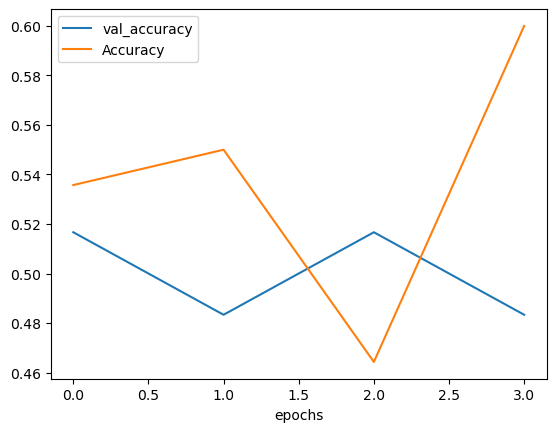

In [21]:
#dibujamos el entrenamiento
import matplotlib.pyplot as plt 
accuracy = h.history['accuracy']
val_accuracy = h.history['val_accuracy']
n_epochs = len(accuracy)
plt.plot(range(0, n_epochs), val_accuracy, label='val_accuracy')
plt.plot(range(0, n_epochs), accuracy, label="Accuracy")

plt.xlabel('epochs')
plt.legend()

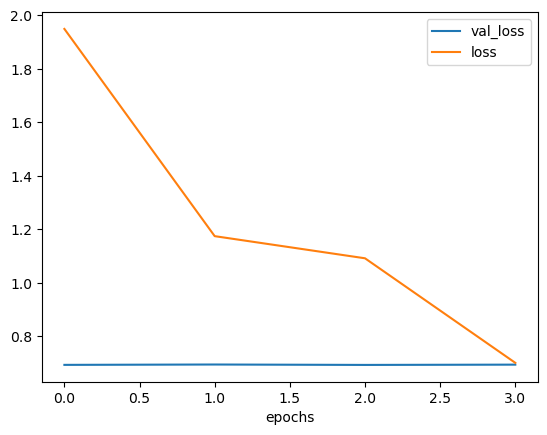

In [22]:
#dibujamos el entrenamiento
import matplotlib.pyplot as plt 
loss = h.history['loss']
val_loss = h.history['val_loss']
n_epochs = len(val_loss)
plt.plot(range(0, n_epochs), val_loss, label='val_loss')
plt.plot(range(0, n_epochs), loss, label="loss")

plt.xlabel('epochs')
plt.legend()